In [176]:
import numpy as np

import xarray as xr
import nc_time_axis

from astropy.table import QTable

import matplotlib.colors as colors

# pyplot needed to plot the dataset, but animation only needed much further down.
from matplotlib import pyplot as plt, animation
%matplotlib inline

# # This is needed to display graphics calculated outside of jupyter notebook
# from IPython.display import HTML, display

# # Also, in case we haven't created it yet, make sure that we have a directory for images and videos
# ! test -d ../images/Python_Animation && rm -rf ../images/Python_Animation/* || mkdir -p ../images/Python_Animation

import matplotlib.gridspec as gridspec

import cartopy.crs as ccrs


In [116]:
def weighted_temporal_mean(ds, var):
    """
    weight by days in each month
    """
    # Determine the month length
    month_length = ds.time.dt.days_in_month

    # Calculate the weights
    wgts = month_length.groupby("time.year") / month_length.groupby("time.year").sum()

    # Make sure the weights in each year add up to 1
    np.testing.assert_allclose(wgts.groupby("time.year").sum(xr.ALL_DIMS), 1.0)

    # Subset our dataset for our variable
    obs = ds[var]

    # Setup our masking for nan values
    cond = obs.isnull()
    ones = xr.where(cond, 0.0, 1.0)

    # Calculate the numerator
    obs_sum = (obs * wgts).resample(time="AS").sum(dim="time")

    # Calculate the denominator
    ones_out = (ones * wgts).resample(time="AS").sum(dim="time")

    # Return the weighted average
    return obs_sum / ones_out

In [4]:
# define eccentricity range

e_range =['circ']

# define path 

data_dir_file = []

for i in range(len(e_range)):
    data_dir_file.append('/nobackup/pybl/cesm_sims/archive/b.e21.BWma1850.f19_g17.new_'+ e_range[i]+'.001/atm/hist/')
    
# define specific path
# we don't want to show variable ending with 'TOA' because it stands for top of atmosphere and it is used for 
# comparingwith observation with an additional atmospheric layer. To show energy budget, please use EEI=FSNT-FLNT.

Path_V     = []

for i in range(len(data_dir_file)):
    Path_V.append(data_dir_file[i]+'V_'+ e_range[i] +'_obl0.nc') 
    

# Import data
# each file has 5 case elements

V_circ      =[]

for i in range(len(e_range)):

    V_circ.append(xr.open_mfdataset(Path_V[i]))


In [5]:
# define eccentricity range

e_range =['e4']

# define path 

data_dir_file = []

for i in range(len(e_range)):
    data_dir_file.append('/nobackup/pybl/cesm_sims/archive/b.e21.BWma1850.f19_g17.new_'+ e_range[i]+'_test.001/atm/hist/')
    
# define specific path
# we don't want to show variable ending with 'TOA' because it stands for top of atmosphere and it is used for 
# comparingwith observation with an additional atmospheric layer. To show energy budget, please use EEI=FSNT-FLNT.

Path_V     = []


for i in range(len(data_dir_file)):
    Path_V.append(data_dir_file[i]+'V_'+ e_range[i] +'_merge.nc') 

# Import data
# each file has 5 case elements

V_e4      =[]

for i in range(len(e_range)):

    V_e4.append(xr.open_mfdataset(Path_V[i]))




In [12]:
def degtorad(data):
    
    rad=data.lat*np.pi/180
    
    return rad
    
def SF(data):
    '''
    Function to calclate meridional streamfunction
    As detailed in Carone et al. (2018)
    Stratosphere circulation on tidally locked ExoEarths
    
    2piR_p/g cos(nu) intgral(v_bar dp)
    '''
    g = 9.81 #[SI]
    r_p=6371 * 10**3 # [m]
    
#     DS['dp'] = (['lev'], np.gradient(data.lev*100))
    sf = 2 * np.pi * r_p* degtorad(data)* (data.mean(dim = 'lon') * np.gradient(data.lev*100)).cumsum(dim = 'lev') / (g)
    return sf



/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/ipykernel_launcher.py:29: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/ipykernel_launcher.py:35: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/ipykernel_launcher.py:41: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/ipykernel_launcher.py:47: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning

(1000, 1)

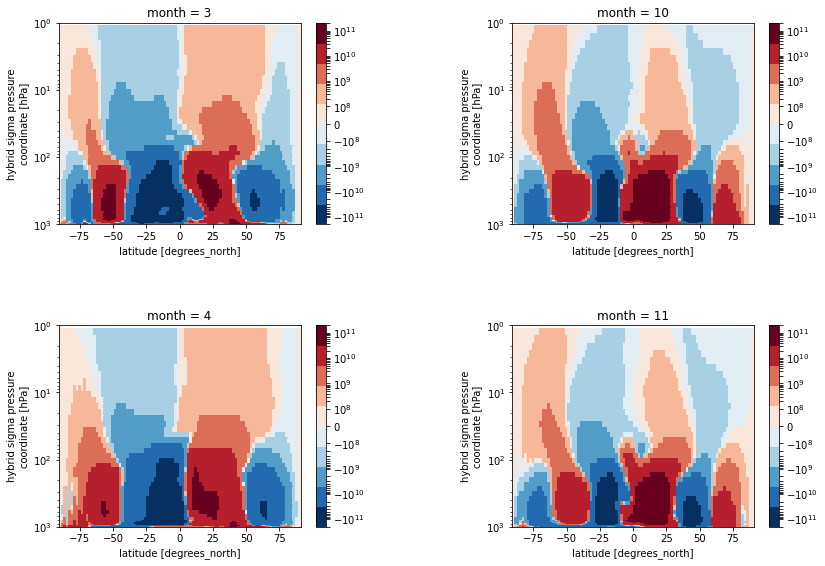

In [186]:
gs = gridspec.GridSpec(2, 2)

plt.figure(figsize=(15,10))

plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.8, 
                    top=0.8, 
                    wspace=0.5, 
                    hspace=0.5)

ax = plt.subplot(gs[0, 0]) # row 0, col 0

linthresh = 1e9;vmax = 2e11; vmin = -2e11


data_e4=V_e4[0].V.sel(time=slice('0012-01', '0016-12')).groupby('time.month').mean(dim='time')
rad=np.cos(data_e4.lat*np.pi/180)
g = 9.81 #[SI]
r_p=6371 * 10**3 # [m]

const_tot=2 * np.pi * r_p* rad /g

data_e4['dp'] = (['lev'], np.gradient(data_e4.lev*100))

sf_e4=const_tot * (data_e4.mean(dim='lon') *data_e4['dp']).cumsum(dim = 'lev')

sf_e4.sel(month=3).where((sf_e4[0].lev > 1) & (sf_e4[0].lev < 1000)).plot(x='lat',ax=ax,yincrease=False,yscale='log',cmap = 'RdBu_r',levels = 11,
                                                                            norm=colors.SymLogNorm(linthresh=10**8,vmax = vmax , vmin = vmin))
plt.ylim(1000,1)

ax = plt.subplot(gs[1, 0]) # row 0, col 0

sf_e4.sel(month=4).where((sf_e4[0].lev > 1) & (sf_e4[0].lev < 1000)).plot(x='lat',ax=ax,yincrease=False,yscale='log',cmap = 'RdBu_r',levels = 11,
                                                                    norm=colors.SymLogNorm(linthresh=10**8,vmax = vmax , vmin = vmin))
plt.ylim(1000,1)

ax = plt.subplot(gs[0, 1]) # row 0, col 0

sf_e4.sel(month=10).where((sf_e4[0].lev > 1) & (sf_e4[0].lev < 1000)).plot(x='lat',ax=ax,yincrease=False,yscale='log',cmap = 'RdBu_r',levels = 11,
                                                                    norm=colors.SymLogNorm(linthresh=10**8,vmax = vmax , vmin = vmin))
plt.ylim(1000,1)

ax = plt.subplot(gs[1, 1]) # row 0, col 0

sf_e4.sel(month=11).where((sf_e4[0].lev > 1) & (sf_e4[0].lev < 1000)).plot(x='lat',ax=ax,yincrease=False,yscale='log',cmap = 'RdBu_r',levels = 11,
                                                                    norm=colors.SymLogNorm(linthresh=10**8,vmax = vmax , vmin = vmin))
plt.ylim(1000,1)




/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/ipykernel_launcher.py:32: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/ipykernel_launcher.py:56: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.


Text(0.5, 1.0, 'e4-e0')

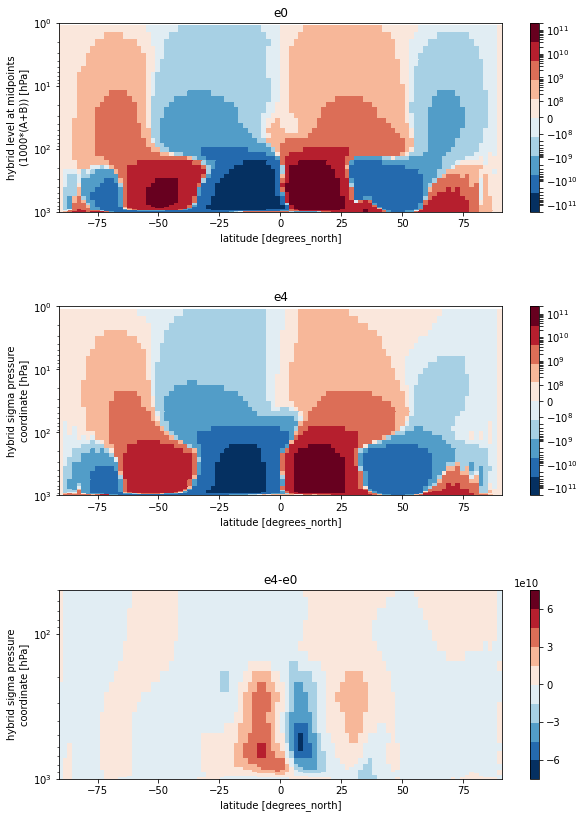

In [191]:
gs = gridspec.GridSpec(3, 1)

plt.figure(figsize=(11,15))

plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.8, 
                    top=0.8, 
                    wspace=0.5, 
                    hspace=0.5)

ax = plt.subplot(gs[0, 0]) # row 0, col 0

linthresh = 1e9;vmax = 2e11; vmin = -2e11


data_circ=weighted_temporal_mean(V_circ[0].sel(time=slice('0012-01', '0016-12')),"V").mean(dim='time')

rad=np.cos(data_circ.lat*np.pi/180)

g = 9.81 #[SI]
r_p=6371 * 10**3 # [m]

const_tot=2 * np.pi * r_p* rad /g

data_circ['dp'] = (['lev'], np.gradient(data_circ.lev*100))

sf_circ=const_tot * (data_circ.mean(dim='lon') *data_circ['dp']).cumsum(dim = 'lev')


sf_circ.where((sf_circ[0].lev > 1) & (sf_circ[0].lev < 1000)).plot(x='lat',ax=ax,yincrease=False,yscale='log',cmap = 'RdBu_r',levels = 11,
                                                                            norm=colors.SymLogNorm(linthresh=10**8,vmax = vmax , vmin = vmin))
plt.ylim(1000,1)
plt.title('e0')

#

ax = plt.subplot(gs[1, 0]) # row 0, col 0


data_e4=weighted_temporal_mean(V_e4[0].sel(time=slice('0012-01', '0016-12')),"V").mean(dim='time')

rad=np.cos(data_e4.lat*np.pi/180)

g = 9.81 #[SI]
r_p=6371 * 10**3 # [m]

const_tot=2 * np.pi * r_p* rad /g

data_e4['dp'] = (['lev'], np.gradient(data_e4.lev*100))

sf_e4=const_tot * (data_e4.mean(dim='lon') *data_e4['dp']).cumsum(dim = 'lev')


sf_e4.where((sf_e4[0].lev > 1) & (sf_e4[0].lev < 1000)).plot(x='lat',ax=ax,yincrease=False,yscale='log',cmap = 'RdBu_r',levels = 11,
                                                                            norm=colors.SymLogNorm(linthresh=10**8,vmax = vmax , vmin = vmin))
plt.ylim(1000,1)
plt.title('e4')
#

ax = plt.subplot(gs[2, 0]) # row 0, col 0


data_e4=weighted_temporal_mean(V_e4[0].sel(time=slice('0012-01', '0016-12')),"V").mean(dim='time')

rad=np.cos(data_e4.lat*np.pi/180)

g = 9.81 #[SI]
r_p=6371 * 10**3 # [m]

const_tot=2 * np.pi * r_p* rad /g

data_e4['dp'] = (['lev'], np.gradient(data_e4.lev*100))

sf_e4=const_tot * (data_e4.mean(dim='lon') *data_e4['dp']).cumsum(dim = 'lev')

(sf_e4-sf_circ).where((sf_e4[0].lev > 50) & (sf_e4[0].lev < 1000)).plot(x='lat',ax=ax,yincrease=False,yscale='log',cmap = 'RdBu_r',levels = 11,
                                                                           )
plt.ylim(1000,50)

plt.title('e4-e0')


/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/ipykernel_launcher.py:19: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/ipykernel_launcher.py:19: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/ipykernel_launcher.py:19: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning specify the base keyword argument.
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/ipykernel_launcher.py:19: MatplotlibDeprecationWarning: default base will change from np.e to 10 in 3.4.  To suppress this warning

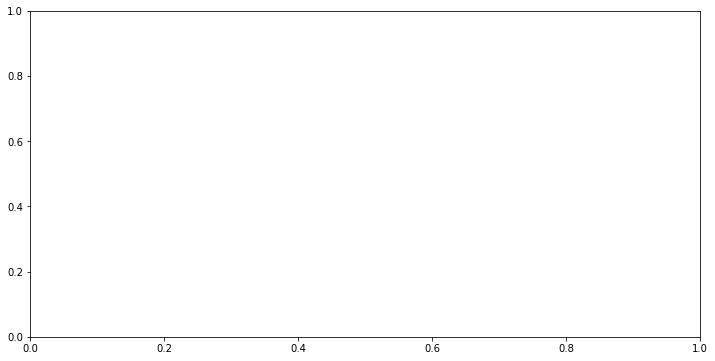

In [170]:
# # Get a handle on the figure and the axes

# fig, ax = plt.subplots(figsize=(12,6))

# tas=sf_e4.where((sf_e4[0].lev > 50) & (sf_e4[0].lev < 1000))

# tas.attrs['units'] = 'kg/s'

# tas.attrs['Stream Function'] = "Stream Function"

# # Plot the initial frame. 

# # cax =tas[:,0,:].plot(x='lat',yincrease=False,yscale='log',cmap = 'RdBu_r',levels = 11,ylim=(1000,50),
# #                     norm=colors.SymLogNorm(linthresh=10**8,vmax = vmax , vmin = vmin))


# for i in range(12):
#     tas[:,i,:].plot(figsize = (12,6),x='lat',yincrease=False,yscale='log',cmap = 'RdBu_r',levels = 11,ylim=(1000,50),
#                     norm=colors.SymLogNorm(linthresh=10**8,vmax = vmax , vmin = vmin))
    
#     plt.title("Time = " + str(tas.coords['month'].values[i])[:13])
#     plt.savefig(f"../images/Python_Animation/SF_{i:12}.png")
#     plt.close()
    
